In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("./base.jl")

In [176]:
using ColorSchemes

In [3]:
includet("../../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

In [156]:
function get_ps(params, K)
    ps = copy(params)
    ps.K[iri] = K
    ps
end

get_ps (generic function with 2 methods)

In [181]:
function make_scale_func(xs)
    mi, mx = extrema(xs)
    d = mx - mi
    if d < eps()
        nothing
    else
        x -> (x - mi) / d
    end
end

make_scale_func (generic function with 1 method)

In [157]:
function run_many_Ks(Ks, ps, T;
    N0=100000.,
    solver=QNDF,
    tol=1e-9,
    maxtime=30,
    surv_threshold=1e-9,
    iri = findfirst(!iszero, ps.K),
)
    N, M = get_Ns(ps)
    si_u0 = [fill(N0, N); fill(0., M)]
    
    num_Ks = length(Ks)
    
    params = Vector{BMMiCRMParams}(undef, num_Ks)
    retcodes = Vector{ReturnCode.T}(undef, num_Ks)
    final_states = Vector{Vector{Float64}}(undef, num_Ks)
    final_Ts = Vector{Float64}(undef, num_Ks)
    maxresids = Vector{Float64}(undef, num_Ks)
    num_surv = Vector{Int}(undef, num_Ks)
    
    @tasks for i in 1:num_Ks
        si_ps = copy(ps)
        si_ps.K[iri] = Ks[i]

        si_p = make_mmicrm_problem(si_ps, si_u0, T)
        si_s = solve(si_p, solver();
            dense=false,
            save_everystep=false,
            callback=CallbackSet(make_timer_callback(maxtime), make_ode_extinction_exit_callback(N, tol / 10), PositiveDomain(si_u0)),
            abstol=tol,
            reltol=tol,
        )
        si_fs = si_s.u[end]
        
        params[i] = si_ps
        retcodes[i] = si_s.retcode
        final_states[i] = si_fs
        final_Ts[i] = si_s.t[end]
        maxresids[i] = mmicrmmaxresid(si_s)
        num_surv[i] = count(>(surv_threshold), si_fs[1:N])
    end

    DataFrame(;
        Ks, params, retcodes, final_states, final_Ts, maxresids, num_surv,
    )
end

run_many_Ks (generic function with 1 method)

In [247]:
N = 20
M = 20
l = 0.99
p = 1.
DN = 0.

rsg = get_si_sampler_for_paper(1000., l, DN; DR=p, N, M);

In [257]:
gen_ps = rsg()
si_ps = gen_ps.mmicrm_params
si_Ds = gen_ps.Ds
iri = findfirst(!iszero, si_ps.K)

4

In [258]:
# Ks = range(0., 1000, 20)
Ks = 10 .^ range(0.2, 2, 20)
df = run_many_Ks(Ks, si_ps, 1e8; maxtime=10);
maximum(df.maxresids)

2.5854168967606048e-8

In [259]:
df.tot_biom = map(df.final_states) do fs
    sum(fs[1:N])
end;

## First plots

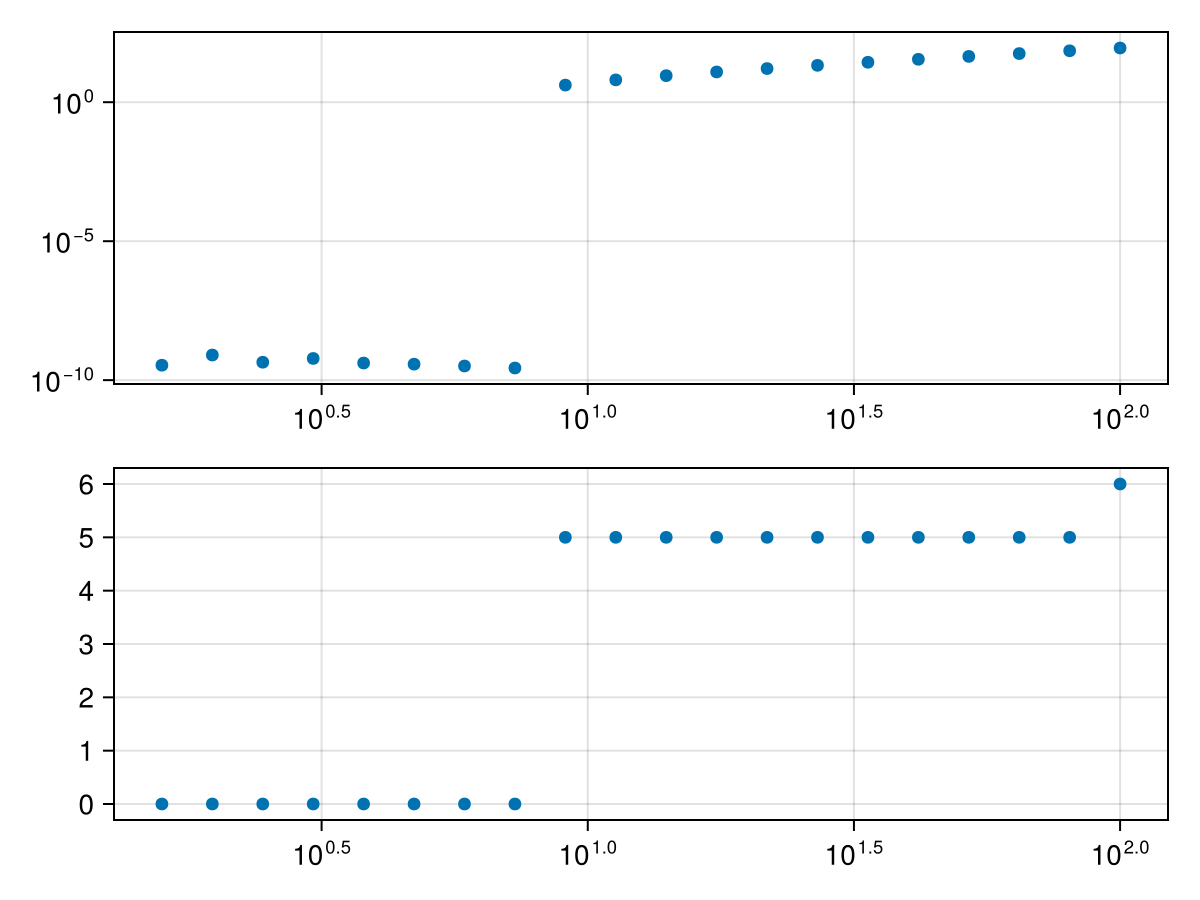

In [260]:
fap = scatter(df.Ks, df.tot_biom;
    axis=(; xscale=log10, yscale=log10)
)
ax2 = Axis(fap.figure[2,1]; xscale=log10)
scatter!(ax2, df.Ks, df.num_surv)
fap

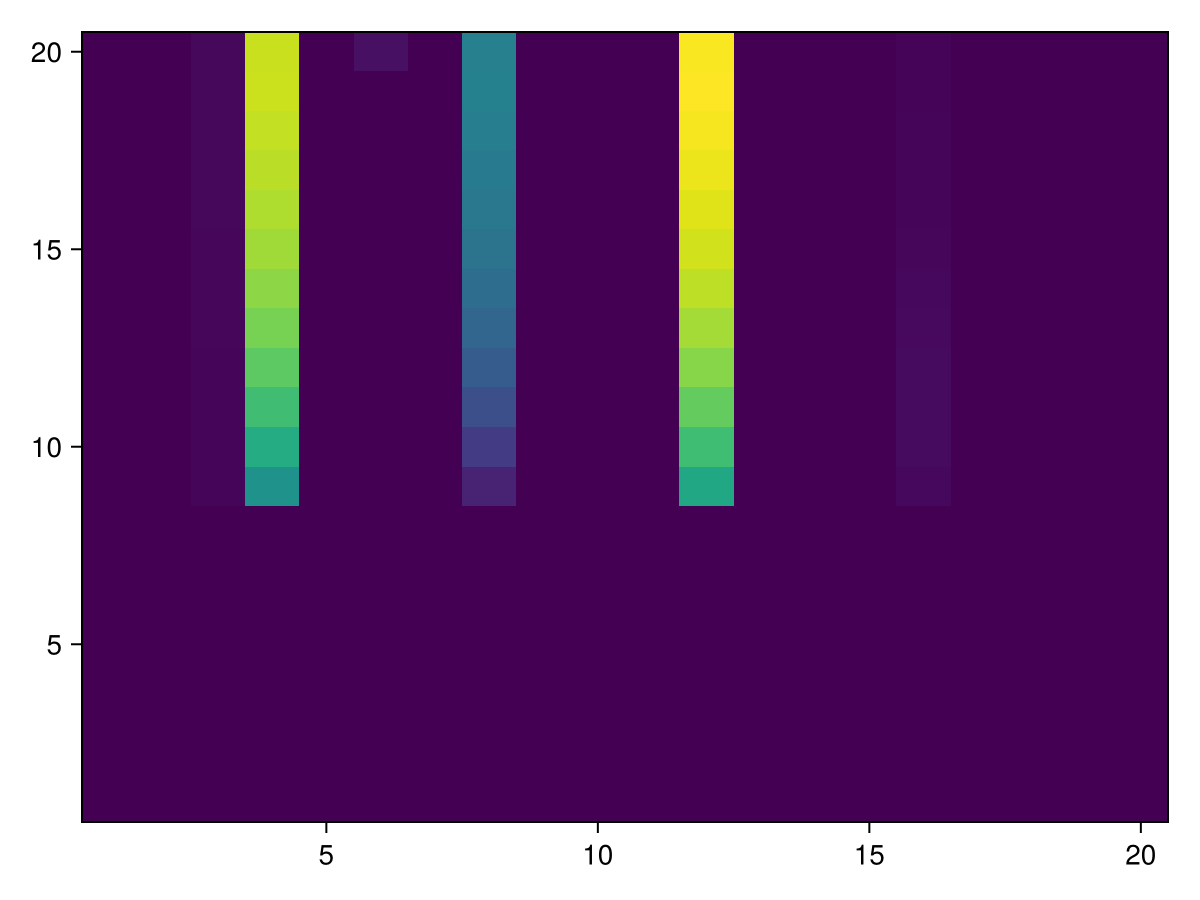

In [261]:
heatmap(hcat(map(zip(df.Ks, df.final_states)) do (K, fs) fs[1:N] ./ K end...))

## Looking at SI disprels with K

In [266]:
findmax(2:11)

(11, 10)

In [308]:
function add_disprels!(df, si_Ds, ks; ls_threshold=1e-9)
    df.ls_evals = tmap(eachrow(df)) do r
        linstab_simple(r.params, si_Ds, r.final_states, ks; returnobj=:evals)
    end
    df.ls_revals = real(df.ls_evals)
    df.mrls = map(df.ls_revals) do revals
        getindex.(revals, 1)
    end
    
    df.nmm_mrls = tmap(eachrow(df)) do r
        get_naive_mm_mrls(ks, r.Ks, l, p)
    end
    
    xx1 = get_mrl_metrics.(Ref(ks), df.mrls)
    df.k0 = getindex.(xx1, 1)
    df.kmax = getindex.(xx1, 2)
    df.mmrls = getindex.(xx1, 3)

    xx2 = get_mrl_metrics.(Ref(ks), df.nmm_mrls)
    df.nmm_k0 = getindex.(xx2, 1)
    df.nmm_kmax = getindex.(xx2, 2)
    df.nmm_mmrls = getindex.(xx2, 3)
    
    df
end

add_disprels! (generic function with 2 methods)

In [309]:
ks = range(0.01, 1000, 10000)
add_disprels!(df, si_Ds, ks);

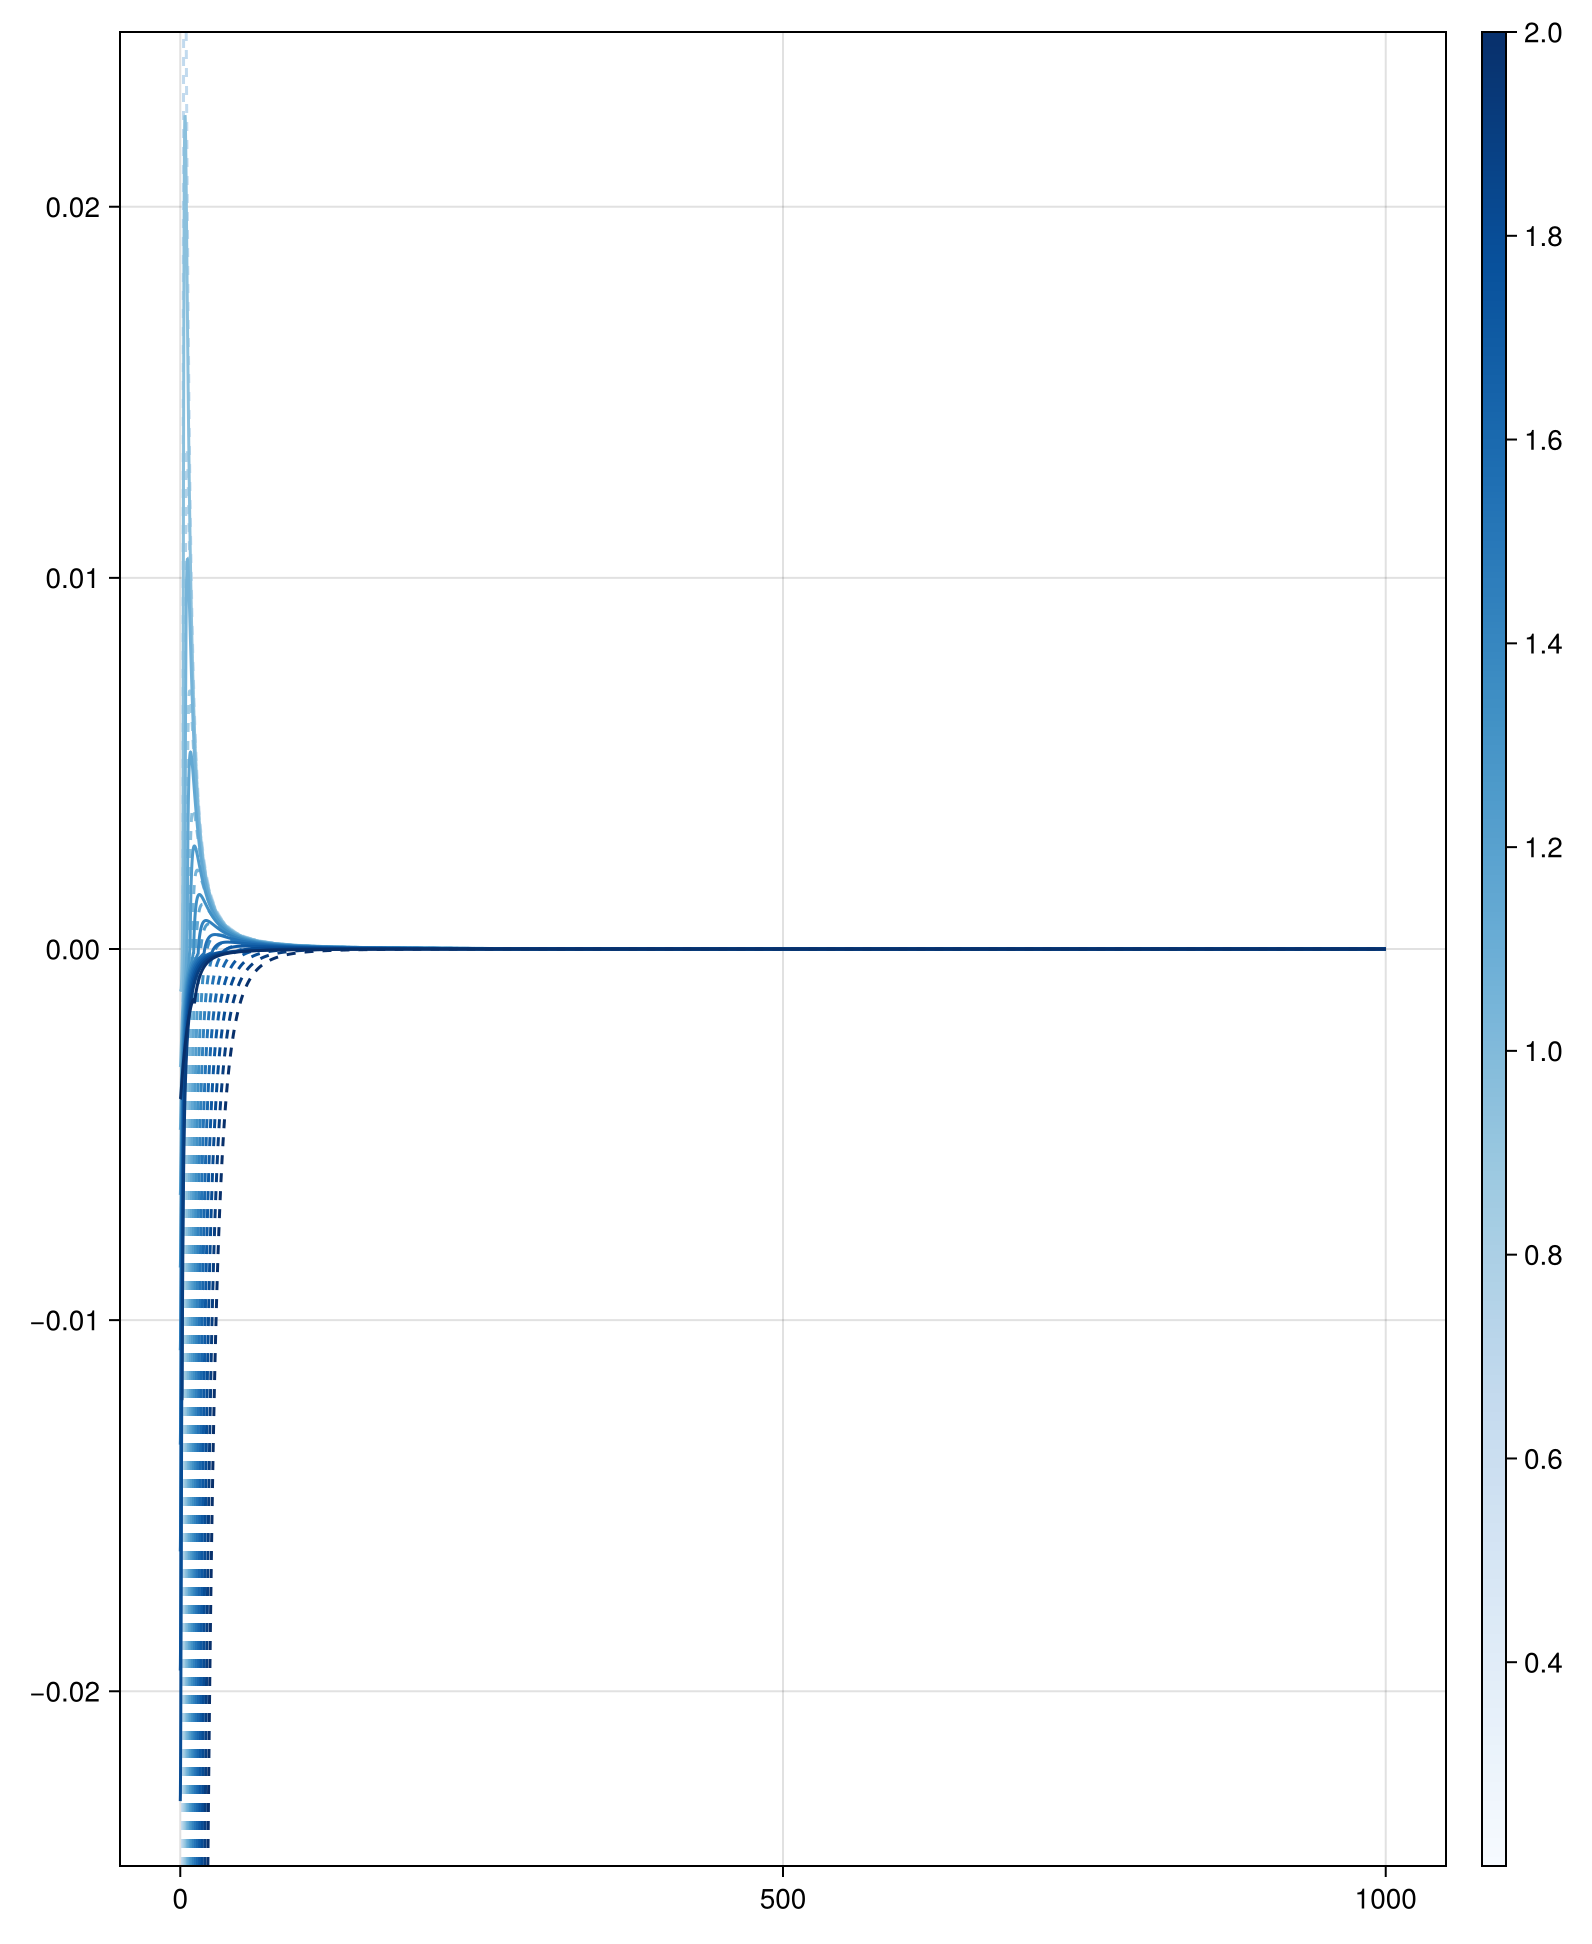

In [316]:
fig = Figure()
ax = Axis(fig[1,1];
    # xscale=log10
)

logKs = log10.(df.Ks)
cscale = make_scale_func(logKs)
cmap = ColorSchemes.Blues

for r in eachrow(df)
    col = get(cmap, cscale(log10(r.Ks)))

    lines!(ax, ks, r.mrls;
        color=col
    )

    nmm_mrls = get_naive_mm_mrls(ks, r.Ks, l, p)
    lines!(ax, ks, nmm_mrls;
        color=col,
        # color=:black,
        linestyle=:dash,
    )
end
Colorbar(fig[1,2]; limits=extrema(logKs), colormap=cmap)

mm = abs(maximum(filter(!ismissing, df.mmrls)))
ylims!(ax, -1.1mm, 1.1mm)

display(GLMakie.Screen(), fig)

fig

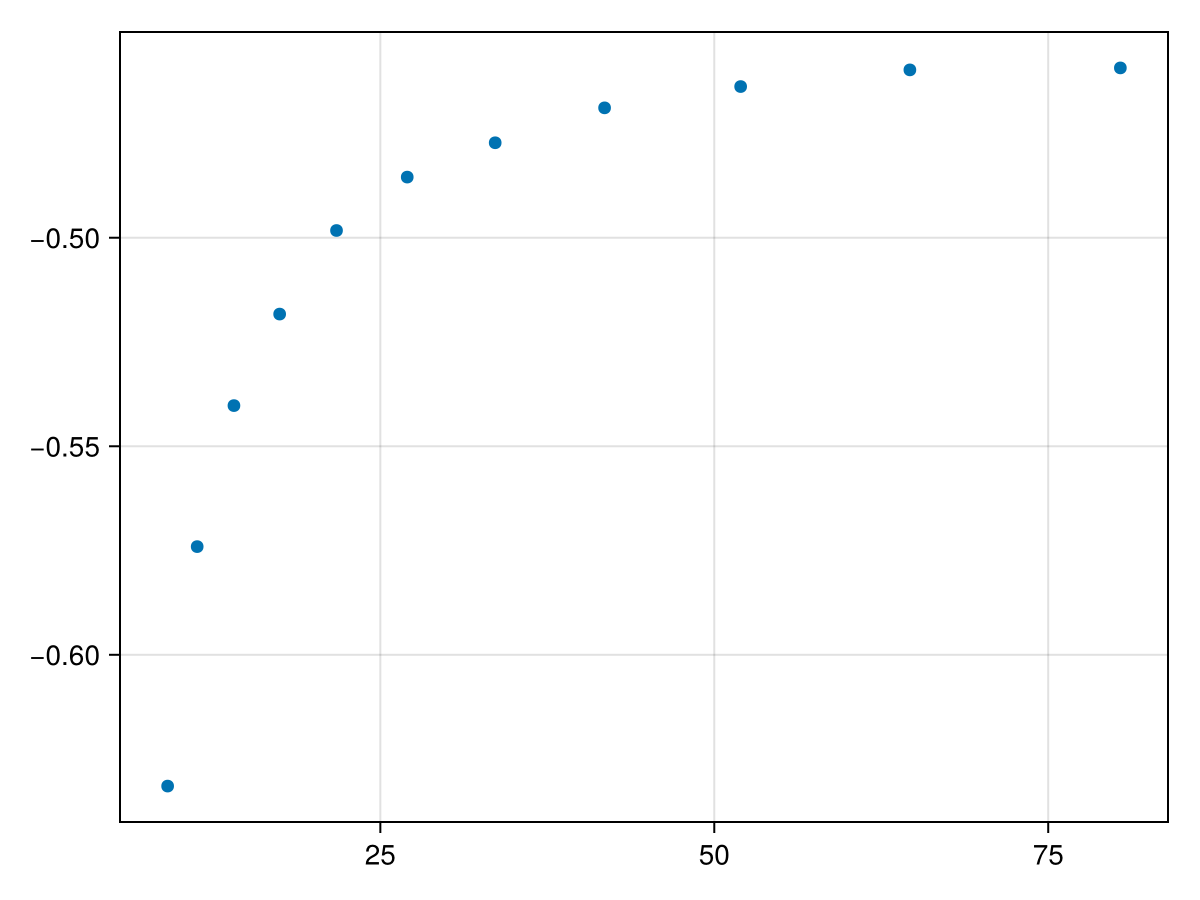

In [318]:
scatter(df.Ks, (df.kmax .- df.nmm_kmax) ./ df.nmm_kmax)

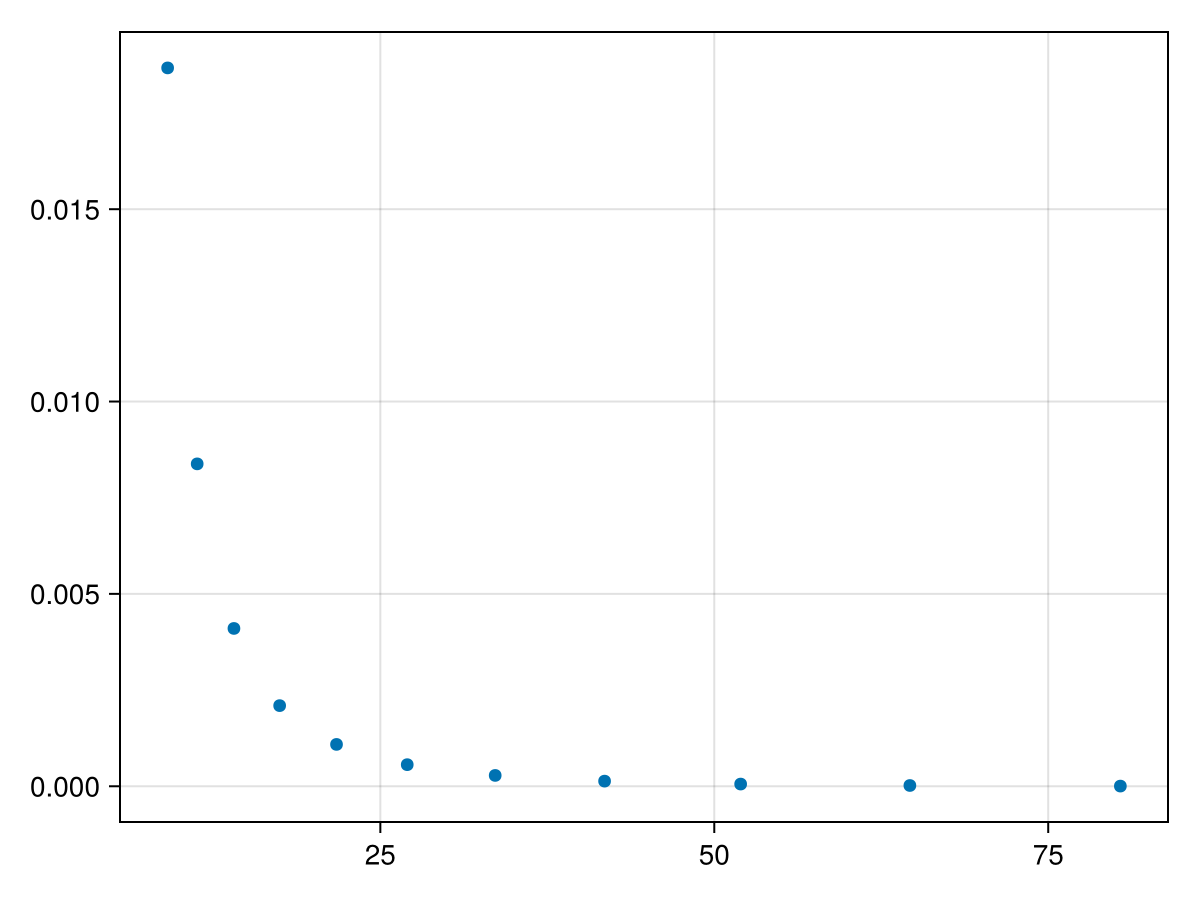

In [313]:
scatter(df.Ks, df.mmrls .- df.nmm_mmrls)

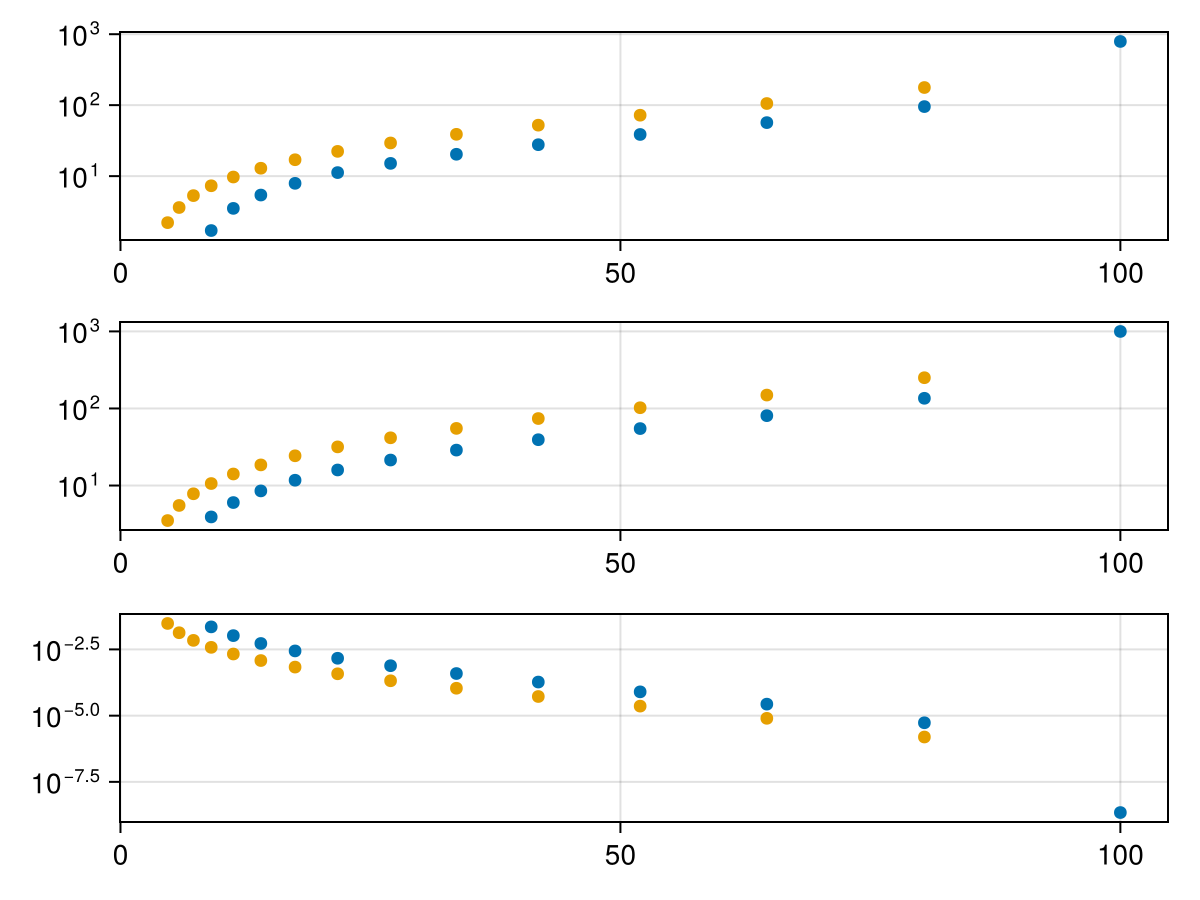

In [311]:
fig = Figure()

ax1 = Axis(fig[1,1]; yscale=log10)
scatter!(ax1, df.Ks, df.k0)
scatter!(ax1, df.Ks, df.nmm_k0)

ax2 = Axis(fig[2,1]; yscale=log10)
scatter!(ax2, df.Ks, df.kmax)
scatter!(ax2, df.Ks, df.nmm_kmax)

ax3 = Axis(fig[3,1]; yscale=log10)
scatter!(ax3, df.Ks, df.mmrls)
scatter!(ax3, df.Ks, df.nmm_mmrls)

fig